#  SWMAL Opgave

## Dataanalyse

### Qa) Beskrivelse af datasæt til O4 projekt

I kurset er slutprojektet et bærende element, som I forventes at arbejde på igennem hele kurset
sideløbende med de forskellige undervisningsemner. 

I skal selv vælge et O4 projekt–det anbefales at I vælger en problemstilling, hvor der allerede er data til rådighed og en god beskrivelse af data, dataopsamlingsmetode og problemstilling.

I denne opgave skal I:

* a) Give en kort konceptmæssig projektbeskrivelse af Jeres ide til O4 projekt. 

* b) Beskrive jeres valgte datasæt med en kort forklaring af baggrund og hvor I har fået data fra.

* c) Beskrive data–dvs. hvilke features, antal samples, target værdier, evt. fejl/usikkerheder, etc.

* d) Forklare hvordan I ønsker at anvende datasættet – vil I fx. bruge det til at prædiktere noget
bestemt, lave en regression eller klassifikation, el.lign. 

I vil nok komme til at anvende data også på andre måder i løbet af undervisningen – men det behøver I ikke nævne. Og det er også ok, hvis I ender med at bruge data på en anden måde end planlagt her.

Omfang af beskrivelsen forventes at være 1-2 sider.


### Qb) Dataanalyse af eget datasæt

Lav data analyse på jeres egne data og projekt.

Det indebærer de sædvanlige elementer såsom plotte histogrammer, middelværdi/median/spredning, analysere for outliers/korrupte data, forslag til skalering af data og lignende former for analyse af data.

For nogle typer data (fx billed-data), hvor features ikke har en specifik betydning, er det mest
histogrammer og lignende, som giver mening – det er helt o.k. 


#### NOTE vdr. billeddatasæts

For billeddata fer hver pixel en feature, og alm. analyse beskrevet ovenfor giver ikke indsigt. Prøv i stedet for billeder at beskrive billedformater (JPEG, PNG osv. / RGB, HSV, gråtone, multispektral, etc.), størrelser af billeder, hvordan de er repræsenteret på disk (dirs osv.)

Giv også eksempler på billeder og evt. labels i billedesæt.

Histogrammer kan udføres på enkelte billeder, men kun i forbindelse med labelede områder---og bedst på billesæt med ens baggrunde.

Benytter i lyddata eller video gælder de samme begrænsinger som får billeder her.

### NOTE vdr. valg af datasæt til O4

I har frie hænder til at vælge O4 projekt og tilhørende datasæt og valg af datasæt og ide til O4 her er ikke endelig. 

Dvs. at i løbende kan modificere projektbeskrivelse og, evt. om nødvendigt, vælge et andet datasæt senere, hvis jeres nuværende valg viser sig umuligt (men er en dyr proces). 

Scope af O4 projekt bør også begrænses, så det passer til kurset og til den '_time-box_'ede aflevering.

### a. Concept

We want to build a robust image-classifier that predicts a cat’s breed from a single photo. The initial scope covers five breeds—Bengal, Domestic Shorthair, Maine Coon, Ragdoll, and Siamese, but the architecture will be modular (Each cat breed has their own folder) so adding new classes later requires only dropping more folders into the dataset, re-running the split and re-training or fine-tuning. We normalize inputs consistently, apply conservative augmentations to improve generalization (flip/rotate/brightness/contrast/zoom), and track performance with accuracy and macro-averaged F1. To understand model behavior, we’ll use a confusion matrix and per-class metrics; this is especially useful for visually similar breeds or when classes are imbalanced. The end product is a saved model artifact plus a small script that takes an image path and returns top-1 prediction with confidence, and maybe top-k probabilities for transparency.


### b. Dataset

We use the [Kaggle Cat's Breed Dataset](https://www.kaggle.com/datasets/yapwh1208/cats-breed-dataset), which provides exactly the five classes we target and already follows a directory-per-breed structure. This structure is compatible with standard loaders fx. (Keras `image_dataset_from_directory`) and plays nicely with reproducible train/validation/test splits. The pipeline stays open to growth: if we later collect more images for these breeds or introduce new breeds, we simply add folders with the appropriate names and rerun the preprocessing/splitting steps. This makes it straightforward to scale both the data and the classification without rewriting code.

### c. Dataset description

Each sample is a color photograph (commonly JPEG/PNG in RGB) with non-uniform resolution and aspect ratio. Labels are implicitly defined by folder names, which reduces the chance of metadata drift but can still contain occasional label noise (mis-sorted images). In a quick exploration pass, we verify the directory layout, count the images per class, and check for corrupt files or near-duplicates using a perceptual hash. We look at global summaries like width/height distributions and aspect ratios to inform the target input size and resizing policy (e.g., pad/crop vs. stretch). We also visualize single-image RGB histograms and small grids of random examples per class to spot systematic differences such as background bias (studio shots vs. household environments), lighting extremes, or watermark artifacts. To hold the scope of the project down we won't go through the pictures for background bias, as i might take a lot of time. There might be some issuese which could be mild class imbalance, resolution variance, and varied backgrounds that can mislead the model into learning context instead of the cat. 


### d. Use of dataset

We’ll use the dataset for multiclass classification: given a cat photo, predict one breed among our five classes. Classification fits because the target is a discrete label, not a numeric value (so not regression). We’ll resize and convert to RGB to standardize inputs and stabilize training, then make stratified train/validation/test splits to get fair evaluation. For metrics, we pick accuracy for overall performance and macro-F1 so small classes count equally (We might add a cat breed with not a lot of pictures). We will use a confusion matrix that shows us which breeds the model confuses.

### Sources:

- [Kaggle Cat’s Breed Dataset](https://www.kaggle.com/datasets/yapwh1208/cats-breed-dataset)
- [scikit-learn: train_test_split (stratified splitting)](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)
- [scikit-learn: StratifiedKFold](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedKFold.html)
- [scikit-learn: StratifiedShuffleSplit](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedShuffleSplit.html)
- [scikit-learn: StratifiedGroupKFold](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedGroupKFold.html)
- [scikit-learn: f1_score (use `average="macro"`) ](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html)
- [scikit-learn: confusion_matrix](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html)
- [scikit-learn: ConfusionMatrixDisplay](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html)
- [scikit-learn: classification_report](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html)
- [scikit-learn: cross_validate (multi-metric CV)](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_validate.html)
- [scikit-learn User Guide: Metrics & scoring (classification metrics)](https://scikit-learn.org/stable/modules/model_evaluation.html)
- [scikit-learn User Guide: Cross-validation](https://scikit-learn.org/stable/modules/cross_validation.html)


We start by setting the dataset path, importing the libraries, and configuring plotting so the rest of the notebook knows where the images are and can visualize results consistently.

In [13]:
# Setup: Datapath and imports
DATA_DIR = "CatData/cat_v1"

from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image, UnidentifiedImageError
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8,5)
plt.rcParams["axes.grid"] = True


Next, we scan the class folders, open each image, and record format, color mode, width, height, and aspect ratio to build a simple metadata table.

In [14]:
# Scan dataset (formats, color spaces, sizes)
IMG_EXTS = {".jpg",".jpeg",".png",".bmp",".gif",".tif",".tiff",".webp"}

rows, bad = [], []
root = Path(DATA_DIR)
classes = sorted([d.name for d in root.iterdir() if d.is_dir()])

for cls in classes:
    for p in (root/cls).rglob("*"):
        if p.is_file() and p.suffix.lower() in IMG_EXTS:
            try:
                with Image.open(p) as im:
                    im.load()
                    w, h = im.size
                    rows.append({
                        "path": str(p),
                        "label": cls,
                        "format": im.format,    # JPEG, PNG, ...
                        "mode": im.mode,        # RGB, L, RGBA, ...
                        "width": w,
                        "height": h,
                        "aspect": (w/h if h else np.nan)
                    })
            except (UnidentifiedImageError, OSError):
                bad.append(str(p))

meta = pd.DataFrame(rows)
print(f"Classes: {classes}")
print(f"Total images: {len(meta)}  |  Unreadable: {len(bad)}")
meta.head()


Classes: ['bengal', 'domestic_shorthair', 'maine_coon', 'ragdoll', 'siamese']
Total images: 952  |  Unreadable: 0


,path,label,format,mode,width,height,aspect
0,CatData\cat_v1\bengal\00438-Bengal-cat-snarlin...,bengal,JPEG,RGB,1120,1104,1.014493
1,CatData\cat_v1\bengal\00441-Very-timid-Brown-S...,bengal,JPEG,RGB,1414,1104,1.280797
2,CatData\cat_v1\bengal\00e79f939696ea0c09560315...,bengal,JPEG,RGB,2554,3222,0.792675
3,CatData\cat_v1\bengal\03915-Pair-of-Bengal-kit...,bengal,JPEG,RGB,1102,1104,0.998188
4,CatData\cat_v1\bengal\04413-Bengal-cat-white-b...,bengal,JPEG,RGB,1038,1104,0.940217


Then we print a directory tree to document how the data are organized on disk, showing the root and the class subfolders.

In [15]:
# Representation on disk (folder structure)
def print_tree(path: Path, max_depth=1):
    def _walk(p, prefix="", depth=0):
        if depth > max_depth: return
        entries = sorted(p.iterdir(), key=lambda x: (not x.is_dir(), x.name.lower()))
        for i, e in enumerate(entries[:50]):  # truncate for readability
            is_last = (i == len(entries)-1)
            branch = "└── " if is_last else "├── "
            print(prefix + branch + e.name + ("/" if e.is_dir() else ""))
            if e.is_dir():
                _walk(e, prefix + ("    " if is_last else "│   "), depth+1)
    print(p.name + "/")
    _walk(path)

print_tree(root, max_depth=1)


zxtw5kluwri21.jpg/
├── bengal/
│   ├── 00438-Bengal-cat-snarling.jpg
│   ├── 00441-Very-timid-Brown-Spotted-Bengal-cat-ears-back.jpg
│   ├── 00e79f939696ea0c095603154c4af840.jpg
│   ├── 03915-Pair-of-Bengal-kittens-white-background.jpg
│   ├── 04413-Bengal-cat-white-background.jpg
│   ├── 047ffa2f7165ccc4585e418ddb800299.jpg
│   ├── 05050-Brown-spotted-Bengal-cat-sitting-on-grey-background.jpg
│   ├── 09a0c5d574f818471c84cf509fc786dc.jpg
│   ├── 0c87060cea587a01f0a254066c95deaa.jpg
│   ├── 106f59608bc9fc6ac11df31008efdf94.jpg
│   ├── 1096165.jpg
│   ├── 1111246.jpg
│   ├── 1113154.jpg
│   ├── 1142194.jpg
│   ├── 119mokiL1.jpg
│   ├── 1200px-Bangie_the_Bengal_Cat.jpg
│   ├── 122433177_3649288731759742_6202950879910256561_o.jpg
│   ├── 12651963_f520.jpg
│   ├── 14105889_f520.jpg
│   ├── 15658-Brown-spotted-Bengal-female-cat.jpg
│   ├── 15a0a84bd11fcae601ed41f5672191ba.jpg
│   ├── 1aeae43be56c47450ef4a3354d3e940d.jpg
│   ├── 1b2a68f85a32410fb3fd776927a2f4ef.jpg
│   ├── 1e8351aa322b32f7a23

After that, we show class counts and simple tables of image formats and color modes. This checks how balanced the classes are and what kinds of files we have.

In [16]:
# Basic tables
# Class counts
cls_counts = meta["label"].value_counts().sort_index()
display(pd.DataFrame({"count": cls_counts}))

# Formats & color spaces
display(meta["format"].value_counts().to_frame("count").rename_axis("format"))
display(meta["mode"].value_counts().to_frame("count").rename_axis("mode"))


,count
label,
bengal,177
domestic_shorthair,170
maine_coon,190
ragdoll,207
siamese,208


,count
format,
JPEG,942
PNG,7
MPO,2
WEBP,1


,count
mode,
RGB,947
RGBA,2
P,2
L,1


We then compute size stats per class and plot histograms of width, height, and aspect ratio. This tells us how big images are and helps if we want to choose a standard resize.

width                                  height               \
                   count   min  median         mean   max  count  min  median   
label                                                                           
bengal               177  1024  1500.0  1913.604520  6016    177  768  1200.0   
domestic_shorthair   170  1024  1630.0  2084.317647  7793    170  768  1600.0   
maine_coon           190  1024  1393.0  1710.752632  5616    190  768  1350.0   
ragdoll              207  1024  1530.0  1855.347826  6000    207  768  1448.0   
siamese              208  1024  1536.0  2027.235577  6000    208  768  1488.5   

                                      aspect                                \
                           mean   max  count       min    median      mean   
label                                                                        
bengal              1598.355932  4928    177  0.577622  1.333333  1.250921   
domestic_shorthair  1971.905882  5472    170  0.486477  1.157033  1.124896   
maine_coon          1678.478947  6000    190  0.598822  1.000000  1.096011   
ragdoll             1722.719807  5389    207  0.607389  1.250000  1.155491   
siamese             1799.307692  4630    208  0.495495  1.332845  1.191017   

                             megapix                                         
                         max   count       min  median      mean        max  
label                                                                        
bengal              1.870130     177  0.786432  1.7370  3.835617  24.064000  
domestic_shorthair  1.784917     170  0.786432  2.6650  4.950322  40.484635  
maine_coon          1.901205     190  0.786432  1.9200  3.506636  25.000000  
ragdoll             1.959565     207  0.786432  2.0736  3.815713  24.000000  
siamese             2.370370     208  0.786432  2.2500  4.451752  24.000000

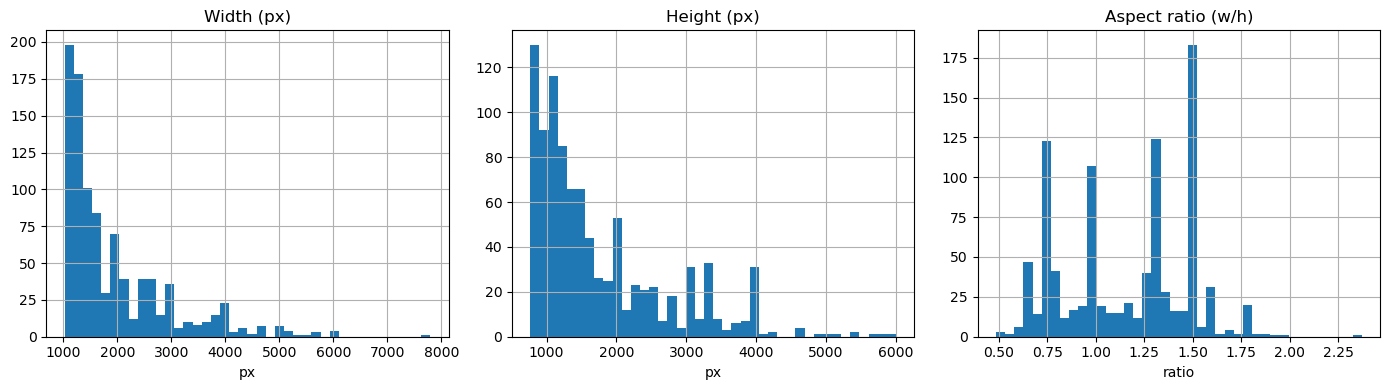

In [17]:
# Size statistics + histograms (width/height/aspect)
size_stats = (meta
    .assign(megapix=(meta["width"]*meta["height"])/1e6)
    .groupby("label")[["width","height","aspect","megapix"]]
    .agg(["count","min","median","mean","max"]))
display(size_stats)

fig, axes = plt.subplots(1,3, figsize=(14,4))
axes[0].hist(meta["width"],  bins=40); axes[0].set_title("Width (px)");  axes[0].set_xlabel("px")
axes[1].hist(meta["height"], bins=40); axes[1].set_title("Height (px)"); axes[1].set_xlabel("px")
axes[2].hist(meta["aspect"], bins=40); axes[2].set_title("Aspect ratio (w/h)"); axes[2].set_xlabel("ratio")
plt.tight_layout(); plt.show()


Next, we show a small grid of example images for each class with their labels. This is a quick visual check that the data look right.

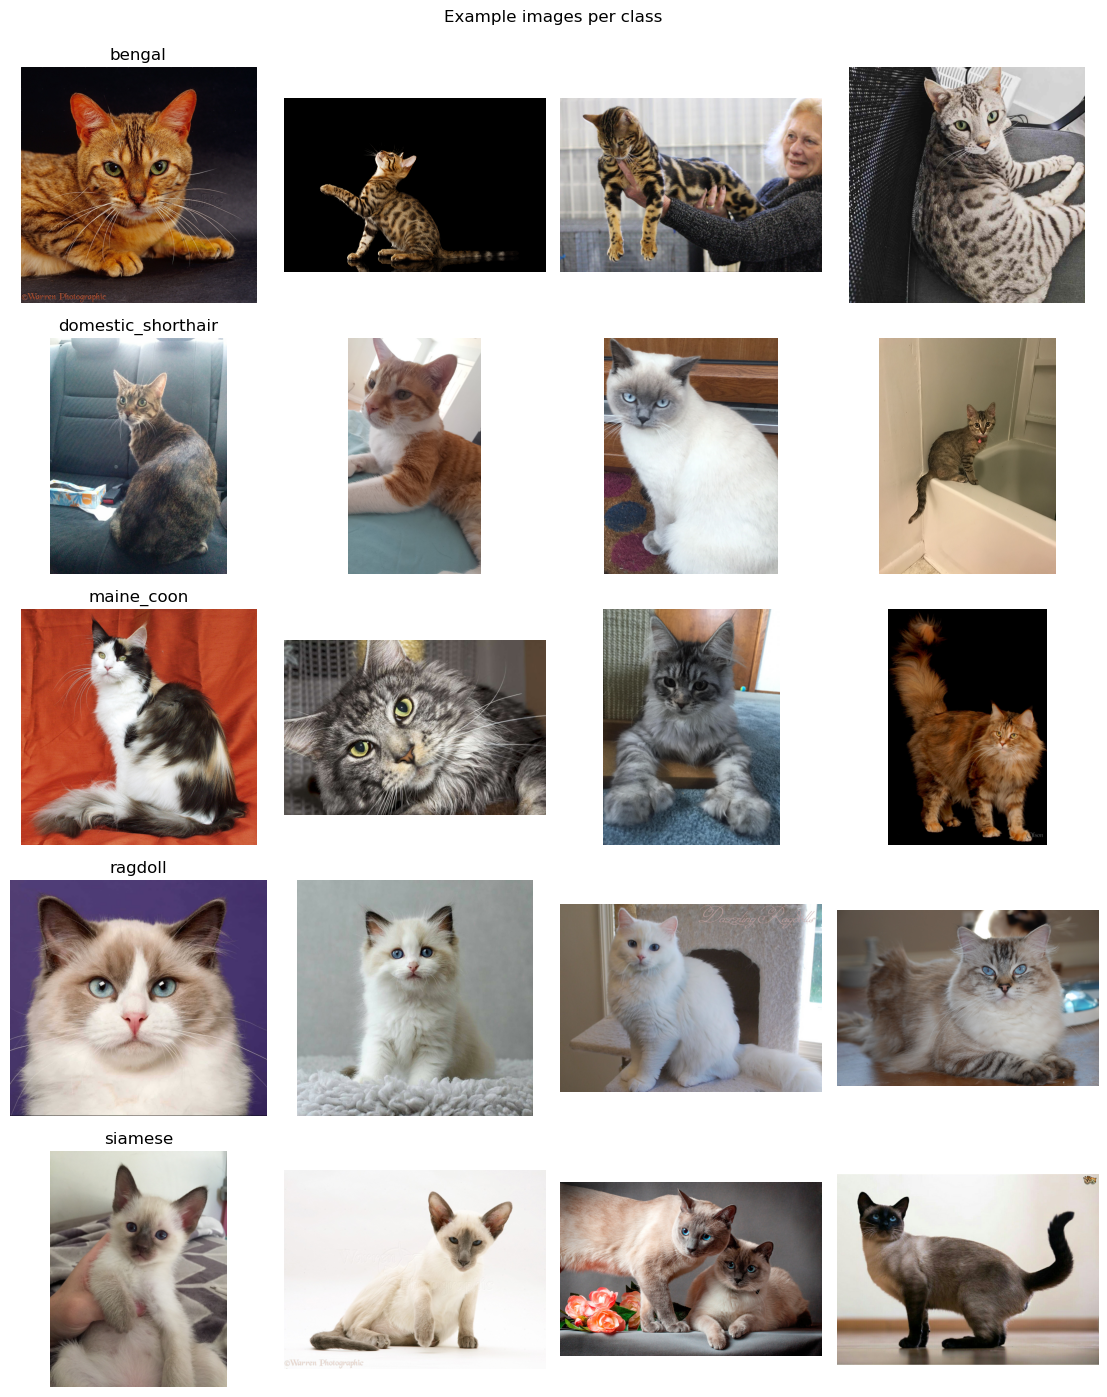

In [18]:
# Examples & labels (image grid)
def show_examples(df, per_class=4):
    labels = sorted(df["label"].unique())
    nrows, ncols = len(labels), per_class
    fig, axes = plt.subplots(nrows, ncols, figsize=(2.8*ncols, 2.8*nrows))
    if nrows == 1: axes = np.array([axes])
    for r, lab in enumerate(labels):
        subset = df[df["label"]==lab]
        sample = subset.sample(min(per_class, len(subset)), random_state=42)
        for c, (_, row) in enumerate(sample.iterrows()):
            ax = axes[r, c] if ncols>1 else axes[r, 0]
            img = Image.open(row["path"]).convert("RGB")
            ax.imshow(img); ax.set_axis_off()
            if c == 0: ax.set_title(lab)
    plt.suptitle("Example images per class", y=0.995)
    plt.tight_layout(); plt.show()

show_examples(meta, per_class=4)


We also plot RGB histograms for one image per class. That gives a basic view of brightness and color for single images.

Single-image histograms (one per class):


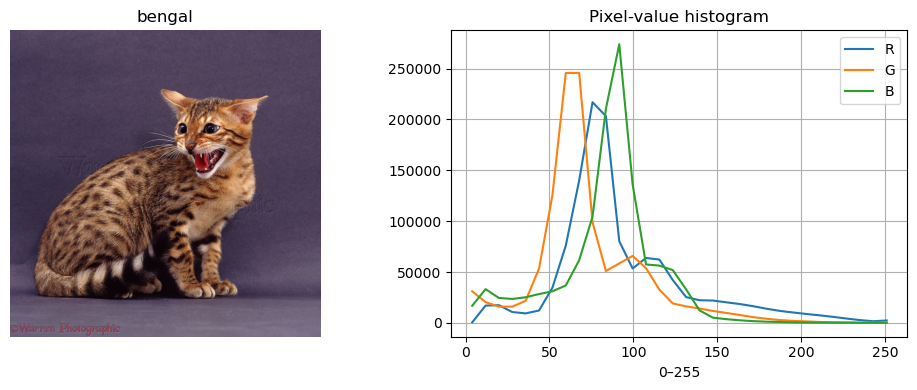

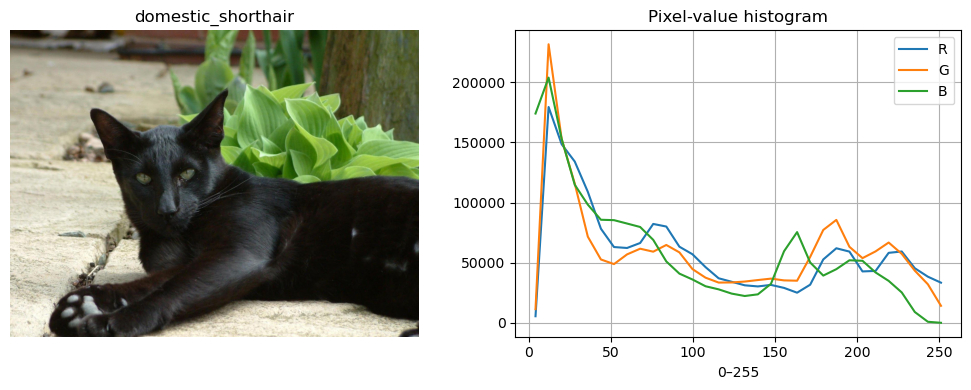

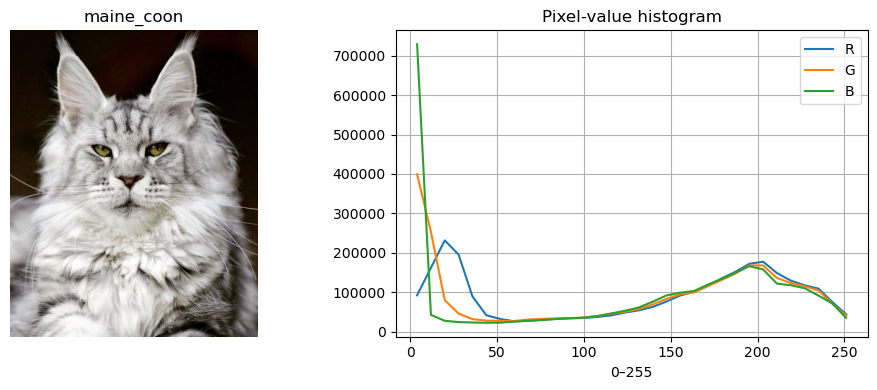

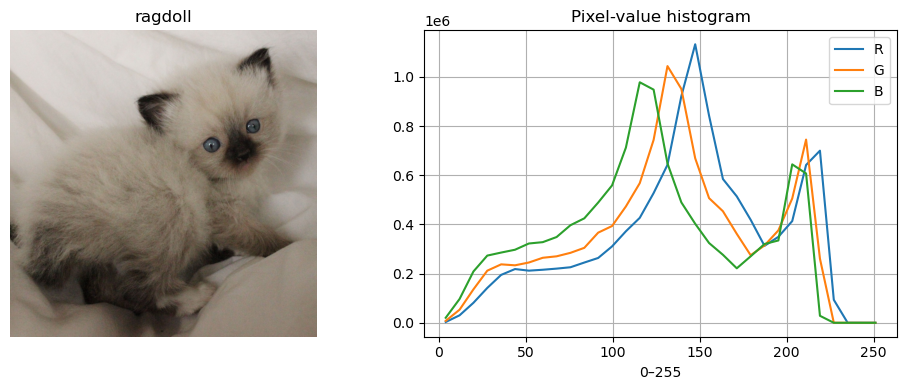

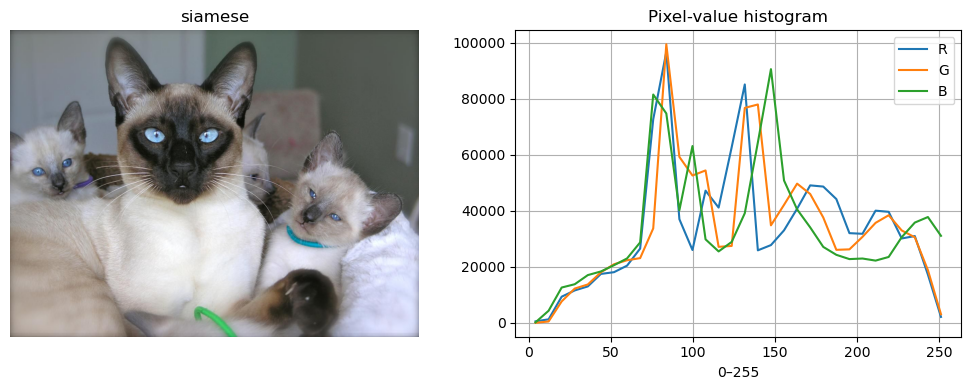

In [19]:
# Histograms on individual images
def plot_image_and_histogram(image_path, bins=32):
    im = Image.open(image_path).convert("RGB")
    arr = np.asarray(im, dtype=np.uint8)
    fig = plt.figure(figsize=(10,4))
    ax1 = plt.subplot(1,2,1)
    ax1.imshow(im); ax1.set_axis_off(); ax1.set_title(Path(image_path).parent.name)
    ax2 = plt.subplot(1,2,2)
    for ch, name in enumerate(["R","G","B"]):
        hist, edges = np.histogram(arr[...,ch].ravel(), bins=bins, range=(0,255))
        centers = 0.5*(edges[1:]+edges[:-1])
        ax2.plot(centers, hist, label=name)
    ax2.set_title("Pixel-value histogram"); ax2.set_xlabel("0–255"); ax2.legend()
    plt.tight_layout(); plt.show()

print("Single-image histograms (one per class):")
for lab in sorted(meta["label"].unique()):
    ex = meta[meta["label"]==lab]
    if len(ex):
        plot_image_and_histogram(ex.iloc[0]["path"], bins=32)


The above data analysis gives us a clear picture of what the dataset includes. We know the folder layout for loaders, the class balance, typical image sizes and aspect ratios, and the formats/color modes. Hopefully this will help us be more prepared for the later challenge of actually training a model.

REVISIONS||
:-|:-|
2021-08-17| CEF, moved from Word to Notebook.
2021-11-08| CEF, elaborated on image based data.
2022-01-25| CEF, update to F22 SWMAL.
2023-02-19| CEF, updated to F23 SWMAL.